In [1]:
# For google colab
# Upload the folder containing this file to google drive if using colab.
import sys, os

# Checking if the notebook is opened in google colab
#If YES, mount the google drive and change the directory
if 'google.colab' in sys.modules:

    # mount google drive
    from google.colab import drive
    drive.mount('/content/drive')

    # change path to the folder
    path = '/content/drive/My Drive/CS5242Project'
    print(path)
    #os.chdir changes the current working directory
    os.chdir(path)
    !pwd


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from transformers import BertTokenizerFast

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset, DataLoader           

from sklearn.utils.class_weight import compute_class_weight

from skorch import NeuralNetClassifier
from skorch.dataset import ValidSplit
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from skorch.helper import predefined_split

from functools import partial
import logging
from logging import StreamHandler

import time

from utils import set_device, load_dataset
from transformer_utils import TransformerNewsDataset, cosine_with_warmup_lr_lambda
from models.bert import Bert

torch.manual_seed(42)
np.random.seed(42)

handler = StreamHandler()
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
handler.setFormatter(formatter)

logger = logging.getLogger()
if logger.hasHandlers():
    logger.handlers.clear()
logger.addHandler(handler)

device = set_device()
print('Using device:', device)

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

datasets = {
    'combined': [
        'data/combined_transformers_train_preprocessed.csv', 
        'data/combined_transformers_test_preprocessed.csv'
        ],
    'base': [
        'data/transformers_train_preprocessed.csv', 
        'data/transformers_test_preprocessed.csv'
        ],  
}

max_length = 128

for k, v in datasets.items():
    for i, t in enumerate(v):
        X, y , classes = load_dataset(t)
        datasets[k][i] = (X, y)
        datasets[k][i] = TransformerNewsDataset(datasets[k][i][0], datasets[k][i][1], tokenizer, max_len=max_length)

train, test = datasets['combined']


Using device: cuda


In [3]:
# Global settings

# tokenizer settings
max_length = 128

# validation dataset settings
USE_TEST_AS_VALID = False 

# learning rate and scheduler settings
lr = 1e-3
num_epochs = 30
batch_size = 64
num_cycles = 0.5
warmup_steps_scaler = 0.1
last_epoch = -1

# training settings
batch_size = 64
max_epochs = 30
loss_func = nn.CrossEntropyLoss
optimizer = torch.optim.AdamW

In [4]:
# Additional calculated variables

if USE_TEST_AS_VALID:
    train_split = predefined_split(test)
else:
    train_split = ValidSplit(0.2, stratified=True)

    
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
total_steps = len(train_loader) * num_epochs
num_warmup_steps = int(warmup_steps_scaler * total_steps)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train.labels), y=train.labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
unique_labels = np.unique(train.labels)

In [5]:
net = partial(NeuralNetClassifier,
    module=partial(Bert, num_labels=len(unique_labels)),
    criterion=partial(loss_func, weight=class_weights_tensor),
    optimizer=optimizer,
    lr=lr,
    batch_size=batch_size,
    max_epochs=max_epochs,
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(
            policy=LambdaLR,
            lr_lambda=partial(
                cosine_with_warmup_lr_lambda, 
                num_warmup_steps=num_warmup_steps, 
                num_cyles=num_cycles
            ),
            last_epoch=last_epoch
                   ),
        EarlyStopping(monitor='valid_f1', patience=5, lower_is_better=False)
    ]
    )

net = net(train_split=train_split)

In [6]:
print('Training combined dataset net')
net.fit(train, torch.tensor(train.labels))
print('=' * 10)

Training combined datset net
  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr      dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  -------
      1       0.0921      0.0407        1.7136       0.0964      0.0378        1.7237  0.0000  37.0921
      2       0.1776      0.1295        1.6209       0.2613      0.2756        1.5516  0.0000  37.2178
      3       0.3427      0.3633        1.4894       0.4336      0.4669        1.3968  0.0000  37.3143
      4       0.5144      0.5348        1.2579       0.6029      0.6156        1.1772  0.0000  37.2872
      5       0.6741      0.6868        0.9048       0.6964      0.7050        1.0044  0.0000  37.2988
      6       0.8034      0.8083        0.5664       0.7577      0.7640        0.8366  0.0000  37.3236
      7       0.8630      0.8654        0.3710       0.8263      0.8191        0.8859  0.0000  37.3259
      8       0.9149      0.9158        0.24

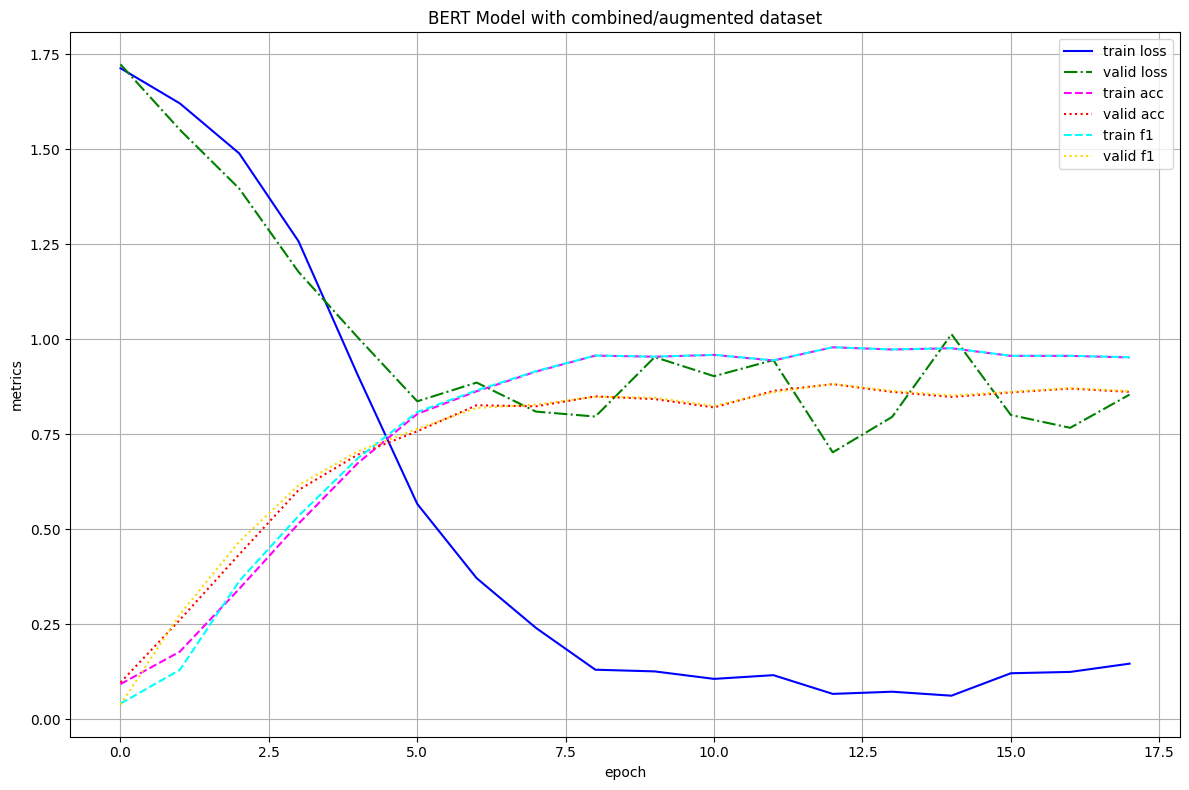

In [7]:
from utils import plot_result_curves

plot_result_curves(net, 'BERT Model with combined/augmented dataset');

# Evaluation

This notebook uses the combined dataset, with the same BERT model as before and from the chart above, it looks like it performs better and can generalize better compared to the base dataset. Validation loss slowed at around the fifth epoch, and fluctuated till peaking at around epoch 13. Similarly, the weighted f1 score peaked at around 0.8824 in epoch 13 for the validation set. 

In [8]:
y_pred = net.predict(test.embed_all())
y_prob = net.predict_proba(test.embed_all())

In [9]:
from utils import print_evaluation_report

print_evaluation_report(y_pred, test, classes, 'BERT Combined Dataset')

BERT Combined Dataset Accuracy: 85.53%
BERT Combined Dataset Weighted F1-score: 0.8597

Classification Report:
               precision    recall  f1-score   support

      center     0.5667    0.8193    0.6700        83
   lean left     0.8448    0.7903    0.8167       124
  lean right     0.8636    0.7917    0.8261        72
        left     0.9420    0.9007    0.9209       433
       right     0.8511    0.8276    0.8392       145

    accuracy                         0.8553       857
   macro avg     0.8136    0.8259    0.8146       857
weighted avg     0.8696    0.8553    0.8597       857



# Classification report summary

The new dataset shows BERT achieving a much higher accuracy 85.53% vs  60.41% and a weighted F1-score of 0.8597 vs 0.6104. Showing a huge jump on performance just by augmenting the dataset.

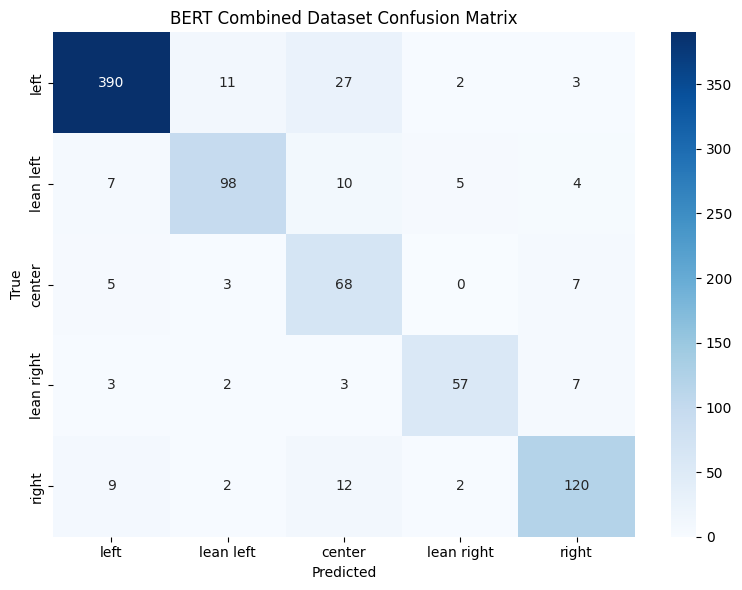

In [10]:
# Define correct label order
from utils import plot_confusion_matrix

plot_confusion_matrix(y_pred, test, classes, 'BERT Combined Dataset');

This iteration of BERT showed significantly better performance in both the dominant and minority classes as well, with a 90% true positive rate (vs 76.6% on the original dataset) on the dominant class and 82% TP rate on the 'right' label (vs 42% in the original dataset)

In [11]:
from utils import show_one_vs_rest_confusion_matrices

print('Confusion matrics for BERT Combined Dataset')
show_one_vs_rest_confusion_matrices(net, y_pred, test, classes)

Confusion matrics for BERT Combined Dataset

One-vs-Rest Confusion Matrix for class 'center':
[[722  52]
 [ 15  68]]

One-vs-Rest Confusion Matrix for class 'lean left':
[[715  18]
 [ 26  98]]

One-vs-Rest Confusion Matrix for class 'lean right':
[[776   9]
 [ 15  57]]

One-vs-Rest Confusion Matrix for class 'left':
[[400  24]
 [ 43 390]]

One-vs-Rest Confusion Matrix for class 'right':
[[691  21]
 [ 25 120]]


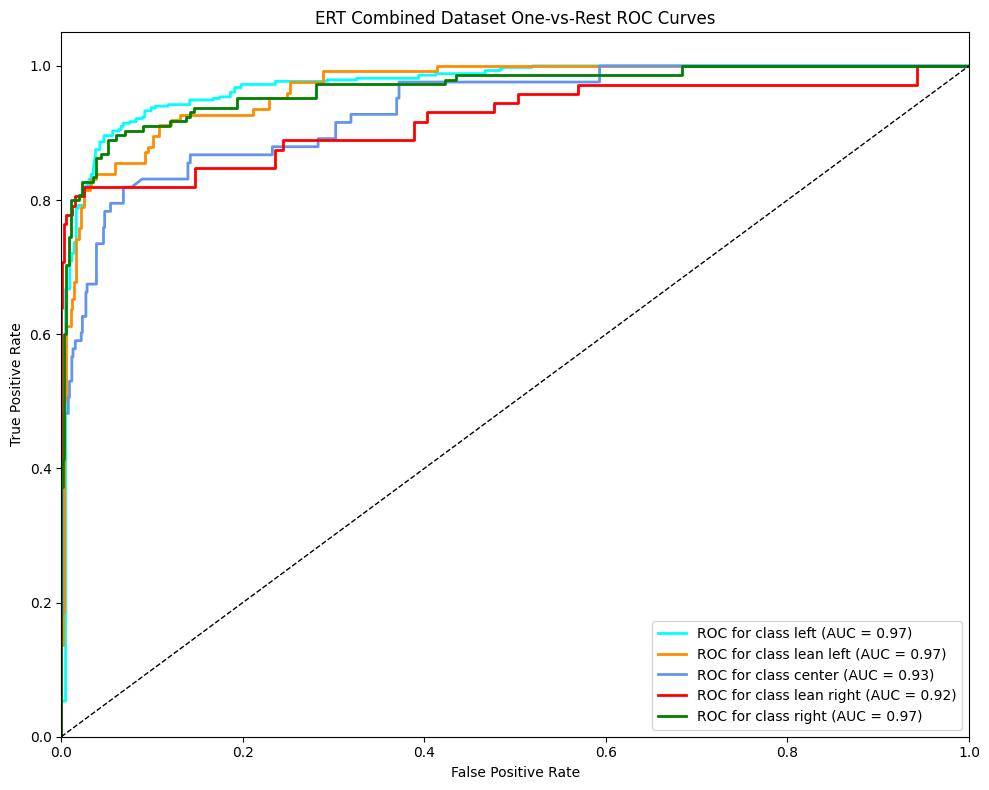

In [12]:
from utils import plot_roc

plot_roc(y_prob, net, test, classes, 'ERT Combined Dataset');

### Performance Metrics Evaluation Summary

| Model            | Accuracy | Weighted F1 |
|------------------|----------|-------------|
| base data        | 60.41    | 61.04       |
| combined data    | 85.53    | 85.97       |